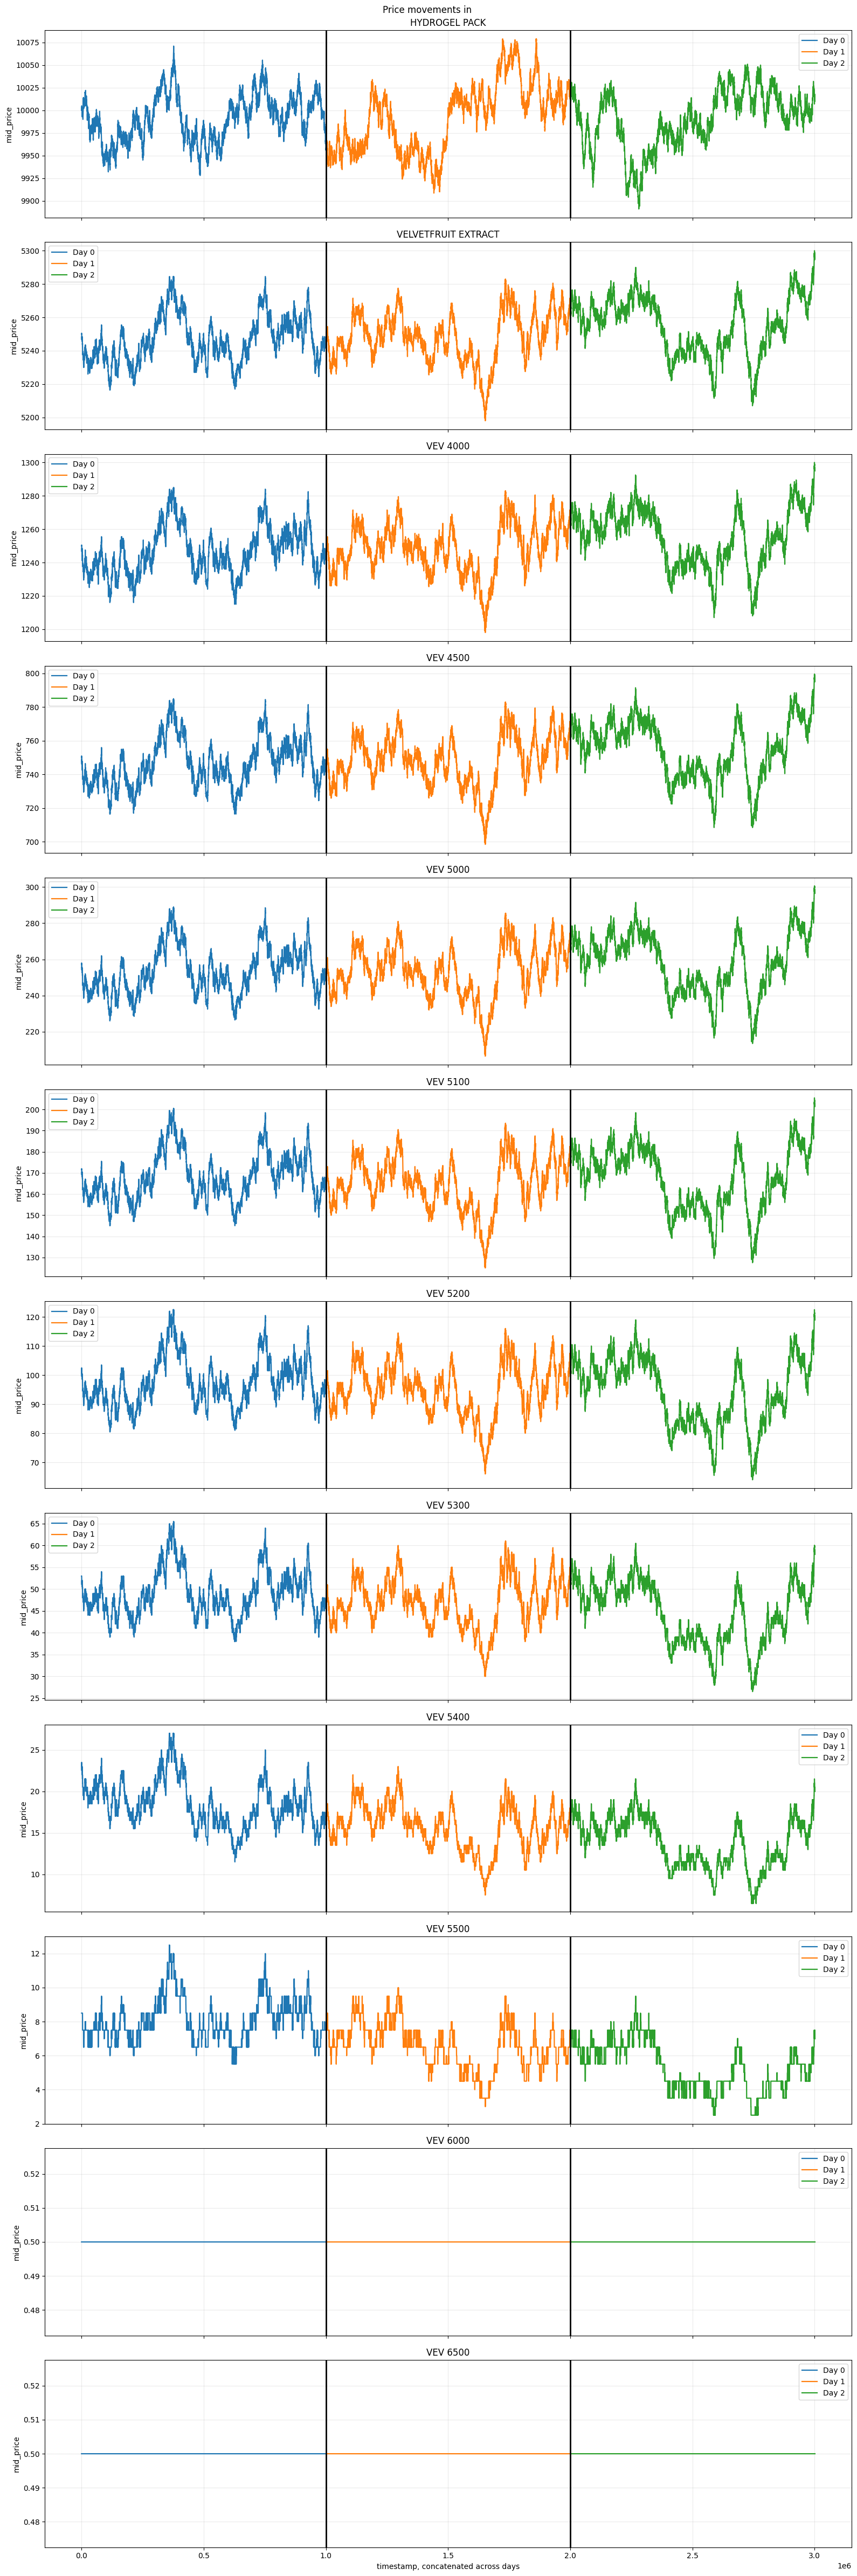

In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 3
ROUND_FOLDER = Path(".")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


In [46]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets


PRODUCTS = ("EMERALDS", "TOMATOES")
LEVELS = (1, 2, 3)


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in search_roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


def cumulative_depth(row: pd.Series, side: str) -> tuple[list[float], list[float]]:
    price_volume: dict[float, float] = {}

    for level in LEVELS:
        price = row.get(f"{side}_price_{level}")
        volume = row.get(f"{side}_volume_{level}")

        if pd.isna(price) or pd.isna(volume) or volume <= 0:
            continue

        price_value = float(price)
        volume_value = float(volume)
        price_volume[price_value] = price_volume.get(price_value, 0.0) + volume_value

    if not price_volume:
        return [], []

    reverse = side == "bid"
    prices = sorted(price_volume.keys(), reverse=reverse)

    cumulative = []
    running = 0.0
    for price in prices:
        running += price_volume[price]
        cumulative.append(running)

    return prices, cumulative


def draw_product_depth(ax: plt.Axes, row: pd.Series, product: str) -> None:
    ax.clear()

    bid_prices, bid_cum = cumulative_depth(row, "bid")
    ask_prices, ask_cum = cumulative_depth(row, "ask")

    if bid_prices:
        ax.step(bid_prices, bid_cum, where="post", color="tab:green", linewidth=2, label="Bids")
        ax.fill_between(bid_prices, bid_cum, step="post", alpha=0.25, color="tab:green")

    if ask_prices:
        ax.step(ask_prices, ask_cum, where="post", color="tab:red", linewidth=2, label="Asks")
        ax.fill_between(ask_prices, ask_cum, step="post", alpha=0.25, color="tab:red")

    mid_price = row.get("mid_price")
    if pd.notna(mid_price):
        ax.axvline(float(mid_price), linestyle="--", linewidth=1.5, color="tab:blue", label="Mid")

    best_bid = row.get("bid_price_1")
    best_ask = row.get("ask_price_1")
    spread_text = ""
    if pd.notna(best_bid) and pd.notna(best_ask):
        spread_text = f" | Spread: {float(best_ask) - float(best_bid):.2f}"

    ax.set_title(f"{product}{spread_text}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Cumulative Volume")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def run_visualizer(path: str = "prices_round_0_day_-1.csv") -> None:
    df = load_prices(path)

    filtered = df[df["product"].isin(PRODUCTS)].copy()
    if filtered.empty:
        raise ValueError("No rows found for EMERALDS or TOMATOES in the provided file.")

    timestamps = sorted(filtered["timestamp"].dropna().unique())
    if not timestamps:
        raise ValueError("No valid timestamp values found in the provided file.")

    data_by_product = {
        product: (
            filtered[filtered["product"] == product]
            .drop_duplicates(subset=["timestamp"], keep="last")
            .set_index("timestamp")
            .sort_index()
        )
        for product in PRODUCTS
    }

    def row_for_timestamp(product: str, timestamp: float) -> pd.Series | None:
        product_df = data_by_product[product]
        if timestamp not in product_df.index:
            return None
        return product_df.loc[timestamp]

    def plot_at_index(index: int) -> None:
        timestamp = timestamps[int(index)]

        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
        ax_emeralds = fig.add_subplot(gs[0, 0])
        ax_tomatoes = fig.add_subplot(gs[0, 1])

        emerald_row = row_for_timestamp("EMERALDS", timestamp)
        tomato_row = row_for_timestamp("TOMATOES", timestamp)

        if emerald_row is not None:
            draw_product_depth(ax_emeralds, emerald_row, "EMERALDS")
        else:
            ax_emeralds.set_title("EMERALDS (no data)")

        if tomato_row is not None:
            draw_product_depth(ax_tomatoes, tomato_row, "TOMATOES")
        else:
            ax_tomatoes.set_title("TOMATOES (no data)")

        fig.suptitle(f"Order Book Depth | timestamp={int(timestamp)}", fontsize=14)
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=len(timestamps) - 1,
        step=1,
        value=min(11, len(timestamps) - 1),
        description="Time idx",
        continuous_update=True,
        layout=widgets.Layout(width="850px"),
    )

    play = widgets.Play(
        value=slider.value,
        min=slider.min,
        max=slider.max,
        step=1,
        interval=100,  # 10 FPS
        description="Auto",
    )

    play_pause = widgets.ToggleButton(
        value=False,
        description="▶ Play",
        tooltip="Play/Pause at 10 FPS",
        layout=widgets.Layout(width="120px"),
    )

    widgets.jslink((play, "value"), (slider, "value"))

    def on_play_pause(change):
        is_playing = bool(change["new"])
        play_pause.description = "⏸ Pause" if is_playing else "▶ Play"
        if hasattr(play, "playing"):
            play.playing = is_playing
        else:
            play._playing = is_playing

    play_pause.observe(on_play_pause, names="value")

    out = widgets.interactive_output(plot_at_index, {"index": slider})
    controls = widgets.HBox([play_pause, play, slider])
    display(controls, out)

In [47]:
def run_price_levels_window_widget(
    prices_csv: str,
    product: str = "HYDROGEL_PACK",
    window_size: int = 50,
    trades_csv: str = "trades_round_3_day_0.csv",
) -> None:
    """Interactive plot of mid/bid/ask price levels with trade overlays."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    trades_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trade_cols = {"timestamp", "symbol", "price"}
    missing_trade_cols = required_trade_cols - set(trades.columns)
    if missing_trade_cols:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trade_cols)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price"])
    trades = trades[trades["symbol"] == asset].copy()

    # Custom midpoint: average(highest ask, lowest bid), where each side uses level 3 if
    # available, otherwise level 2.
    if {"ask_price_2", "ask_price_3"}.issubset(sub.columns):
        sub["best_ask_fallback"] = sub["ask_price_3"].where(sub["ask_price_3"].notna(), sub["ask_price_2"])
    else:
        sub["best_ask_fallback"] = np.nan

    if {"bid_price_2", "bid_price_3"}.issubset(sub.columns):
        sub["best_bid_fallback"] = sub["bid_price_3"].where(sub["bid_price_3"].notna(), sub["bid_price_2"])
    else:
        sub["best_bid_fallback"] = np.nan

    sub["fallback_mid"] = (sub["best_ask_fallback"] + sub["best_bid_fallback"]) / 2.0

    # Additional fallback quote ladders for dotted overlays.
    if {"ask_price_1", "ask_price_2"}.issubset(sub.columns):
        sub["second_ask_fallback"] = sub["ask_price_2"].where(sub["ask_price_2"].notna(), sub["ask_price_1"])
    else:
        sub["second_ask_fallback"] = np.nan

    if {"bid_price_1", "bid_price_2"}.issubset(sub.columns):
        sub["second_bid_fallback"] = sub["bid_price_2"].where(sub["bid_price_2"].notna(), sub["bid_price_1"])
    else:
        sub["second_bid_fallback"] = np.nan

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "mid_price" in w.columns and w["mid_price"].notna().any():
            plt.plot(w["timestamp"], w["mid_price"], color="black", linewidth=2.0, label="mid_price")

        if "fallback_mid" in w.columns and w["fallback_mid"].notna().any():
            plt.plot(
                w["timestamp"],
                w["fallback_mid"],
                color="tab:blue",
                linestyle=":",
                linewidth=2.0,
                alpha=0.95,
                label="fallback_mid (ask3/2 + bid3/2)/2",
            )

        # Dotted fallback quote lines:
        # highest ask (ask3 else ask2), second highest ask (ask2 else ask1),
        # lowest bid (bid3 else bid2), second lowest bid (bid2 else bid1).
        if "best_ask_fallback" in w.columns and w["best_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_ask_fallback"],
                color="#B71C1C",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="highest ask fallback (3->2)",
            )

        if "second_ask_fallback" in w.columns and w["second_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_ask_fallback"],
                color="#E57373",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second highest ask fallback (2->1)",
            )

        if "best_bid_fallback" in w.columns and w["best_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_bid_fallback"],
                color="#1B5E20",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="lowest bid fallback (3->2)",
            )

        if "second_bid_fallback" in w.columns and w["second_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_bid_fallback"],
                color="#81C784",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second lowest bid fallback (2->1)",
            )

        bid_colors = ["#A5D6A7", "#4CAF50", "#1B5E20"]
        if "bid_price_1" in w.columns and w["bid_price_1"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_1"], color=bid_colors[0], linewidth=1.4, alpha=0.95, label="bid_price_1")
        if "bid_price_2" in w.columns and w["bid_price_2"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_2"], color=bid_colors[1], linewidth=1.4, alpha=0.95, label="bid_price_2")
        if "bid_price_3" in w.columns and w["bid_price_3"].notna().any():
            b3 = w[w["bid_price_3"].notna()]
            plt.scatter(b3["timestamp"], b3["bid_price_3"], color=bid_colors[2], s=20, alpha=0.95, label="bid_price_3 (points)")

        ask_colors = ["#FF7F7F", "#D32F2F", "#7B0000"]
        if "ask_price_1" in w.columns and w["ask_price_1"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_1"], color=ask_colors[0], linewidth=1.4, alpha=0.95, label="ask_price_1")
        if "ask_price_2" in w.columns and w["ask_price_2"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_2"], color=ask_colors[1], linewidth=1.4, alpha=0.95, label="ask_price_2")
        if "ask_price_3" in w.columns and w["ask_price_3"].notna().any():
            a3 = w[w["ask_price_3"].notna()]
            plt.scatter(a3["timestamp"], a3["ask_price_3"], color=ask_colors[2], s=20, alpha=0.95, label="ask_price_3 (points)")

        # Overlay trades in current window as X markers.
        t_min = w["timestamp"].min()
        t_max = w["timestamp"].max()
        tw = trades[(trades["timestamp"] >= t_min) & (trades["timestamp"] <= t_max)]
        if not tw.empty:
            plt.scatter(
                tw["timestamp"],
                tw["price"],
                marker="x",
                color="#EFB63A",
                s=72,
                linewidths=3.2,
                alpha=0.9,
                label=f"trades ({len(tw)})",
            )

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Price Levels | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


# Example usage:
run_price_levels_window_widget(
    "prices_round_3_day_0.csv",
    product="HYDROGEL_PACK",
    window_size=50,
    trades_csv="trades_round_3_day_0.csv",
)


Output()

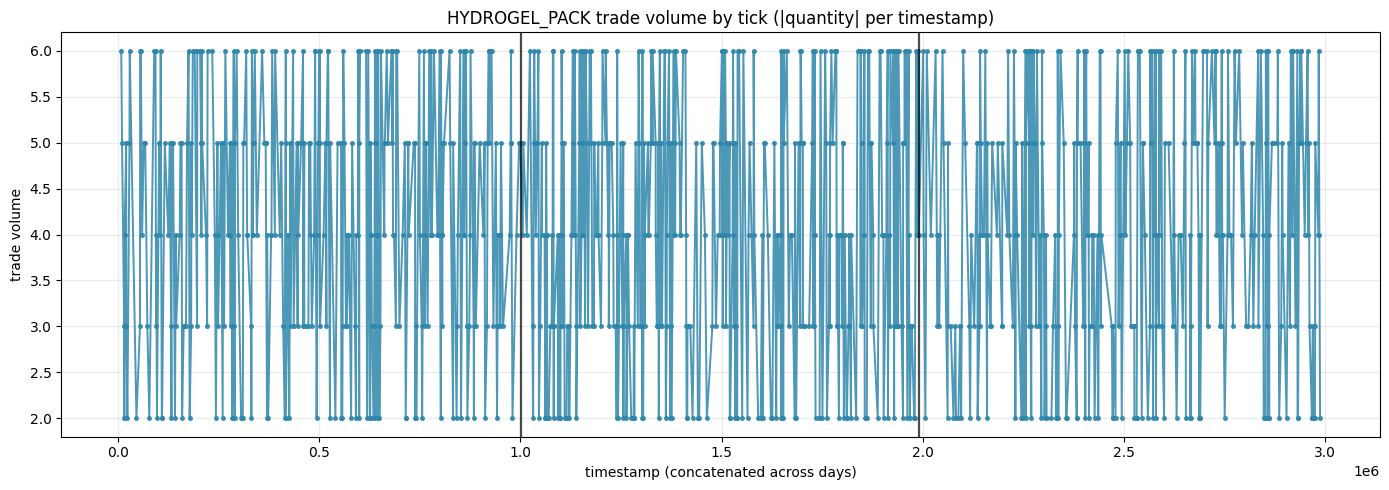

In [48]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

PRODUCT = "HYDROGEL_PACK"
ROUND_NUMBER = 3
TRADE_GLOB = f"trades_round_{ROUND_NUMBER}_day_*.csv"
DAY_RE = re.compile(r"day_(-?\d+)\.csv$")

trade_files = sorted(Path(".").glob(TRADE_GLOB))
if not trade_files:
    raise FileNotFoundError(f"No files matching {TRADE_GLOB!r} found in {Path('.').resolve()}")

frames = []
day_labels = []
for file_path in trade_files:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    day_labels.append(day)

    df = pd.read_csv(file_path, sep=";", engine="python")
    if "symbol" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df.columns = [str(c).strip().lower() for c in df.columns]

    if "quantity" not in df.columns and "volume" in df.columns:
        df["quantity"] = df["volume"]

    required = {"timestamp", "symbol", "quantity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path.name} missing required columns: {sorted(missing)}")

    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df["symbol"] = df["symbol"].astype(str).str.strip().str.upper()

    sub = df[df["symbol"] == PRODUCT].dropna(subset=["timestamp", "quantity"]).copy()
    if sub.empty:
        continue

    sub["day"] = day
    sub["abs_quantity"] = sub["quantity"].abs()

    vol_per_tick = (
        sub.groupby(["day", "timestamp"], as_index=False)["abs_quantity"]
        .sum()
        .sort_values(["day", "timestamp"])
    )
    frames.append(vol_per_tick)

if not frames:
    raise ValueError(f"No trades found for symbol {PRODUCT} in matched files.")

plot_df = pd.concat(frames, ignore_index=True)
day_labels = sorted(set(day_labels))

# Concatenate day timelines into one x-axis, with a small visual gap between days.
gap = 1000.0
x_offsets = {}
separators = []
current_offset = 0.0
for day in day_labels:
    day_slice = plot_df[plot_df["day"] == day]
    max_ts = float(day_slice["timestamp"].max()) if not day_slice.empty else 0.0
    x_offsets[day] = current_offset
    separators.append(current_offset + max_ts + gap / 2.0)
    current_offset += max_ts + gap

plot_df["x"] = plot_df["timestamp"] + plot_df["day"].map(x_offsets)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    plot_df["x"],
    plot_df["abs_quantity"],
    color="#2E86AB",
    linewidth=1.4,
    marker="o",
    markersize=2.6,
    alpha=0.85,
)

for sep in separators[:-1]:
    ax.axvline(sep, color="black", linewidth=1.6, alpha=0.7)

ax.set_title(f"{PRODUCT} trade volume by tick (|quantity| per timestamp)")
ax.set_xlabel("timestamp (concatenated across days)")
ax.set_ylabel("trade volume")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [49]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

PRODUCT = "HYDROGEL_PACK"
ROUND_NUMBER = 3
DAY_RE = re.compile(r"day_(-?\d+)\.csv$")

frames = []
for fp in sorted(Path(".").glob(f"prices_round_{ROUND_NUMBER}_day_*.csv")):
    m = DAY_RE.search(fp.name)
    if not m:
        continue
    day = int(m.group(1))
    df = pd.read_csv(fp, sep=";")
    df.columns = [c.strip().lower() for c in df.columns]
    df["day"] = day
    for col in ["timestamp", "mid_price",
                "bid_price_1", "bid_volume_1", "ask_price_1", "ask_volume_1",
                "bid_price_2", "bid_volume_2", "ask_price_2", "ask_volume_2"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["product"] = df["product"].astype(str).str.strip().str.upper()
    frames.append(df[df["product"] == PRODUCT])

hydro = (
    pd.concat(frames, ignore_index=True)
    .dropna(subset=["timestamp", "mid_price"])
    .sort_values(["day", "timestamp"])
    .reset_index(drop=True)
)
print(f"Loaded {len(hydro):,} rows across days: {sorted(hydro['day'].unique())}")
hydro.head()


Loaded 30,000 rows across days: [np.int64(0), np.int64(1), np.int64(2)]


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0
1,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0
2,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0
3,0,300,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0
4,0,400,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0


In [50]:
# fair_value = midpoint of the deepest populated order-book levels.
# Level 3 is always empty for HYDROGEL_PACK; level 2 is the outer edge.
# Falls back to level 1 if level 2 is missing on either side.
bid_outer = hydro["bid_price_2"].where(hydro["bid_price_2"].notna(), hydro["bid_price_1"])
ask_outer = hydro["ask_price_2"].where(hydro["ask_price_2"].notna(), hydro["ask_price_1"])
hydro["fair_value"] = (bid_outer + ask_outer) / 2.0

n_valid = hydro["fair_value"].notna().sum()
diff    = (hydro["fair_value"] - hydro["mid_price"]).dropna()
print(f"fair_value rows: {n_valid:,}/{len(hydro):,}")
print(f"vs mid_price  mean={diff.mean():.4f}  std={diff.std():.4f}  max_abs={diff.abs().max():.2f}")
hydro[["day","timestamp","mid_price","bid_price_2","ask_price_2","fair_value"]].head()


fair_value rows: 30,000/30,000
vs mid_price  mean=0.0106  std=0.6881  max_abs=3.50


,day,timestamp,mid_price,bid_price_2,ask_price_2,fair_value
0,0,0,10000.0,9990.0,10010.0,10000.0
1,0,100,10000.0,9990.0,10011.0,10000.5
2,0,200,10003.0,9992.0,10013.0,10002.5
3,0,300,10002.0,9992.0,10013.0,10002.5
4,0,400,10003.0,9993.0,10014.0,10003.5


In [51]:
from statsmodels.tsa.stattools import adfuller


def hurst_rs(ts, max_lag=None):
    """R/S Hurst exponent. H<0.5=mean-reverting, H=0.5=random walk, H>0.5=trending."""
    ts = np.asarray(ts, dtype=float)
    n = len(ts)
    max_lag = min(max_lag or n // 4, n // 4)
    lags, rs_means = [], []
    for lag in range(2, max_lag):
        chunks = [ts[j:j + lag] for j in range(0, n - lag, lag)]
        rs_vals = []
        for chunk in chunks:
            dev = np.cumsum(chunk - chunk.mean())
            std = chunk.std(ddof=1)
            if std > 0:
                rs_vals.append((dev.max() - dev.min()) / std)
        if rs_vals:
            lags.append(lag)
            rs_means.append(np.mean(rs_vals))
    if len(lags) < 2:
        return np.nan
    h, _ = np.polyfit(np.log(lags), np.log(rs_means), 1)
    return h


rows = []
for day, grp in hydro.groupby("day"):
    prices = grp["fair_value"].values
    returns = np.diff(prices)

    adf_stat, adf_pval = adfuller(prices, autolag="AIC")[:2]
    h = hurst_rs(prices)
    lag1_ac = pd.Series(returns).autocorr(lag=1)

    rows.append({
        "day": day,
        "n_ticks": len(prices),
        "adf_stat": round(adf_stat, 3),
        "adf_pval": round(adf_pval, 4),
        "stationary?": adf_pval < 0.05,
        "hurst": round(h, 4),
        "lag1_autocorr": round(lag1_ac, 4),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print("\nInterpretation guide:")
print("  ADF p < 0.05  → price is stationary (mean-reverting)")
print("  Hurst < 0.50  → mean-reverting  |  = 0.50 → random walk  |  > 0.50 → trending")
print("  Lag-1 AC < 0  → tick-level mean reversion (each up-tick followed by down-tick on avg)")


 day  n_ticks  adf_stat  adf_pval  stationary?  hurst  lag1_autocorr
   0    10000    -3.595    0.0059         True 0.9846        -0.0396
   1    10000    -2.521    0.1104        False 0.9790        -0.0295
   2    10000    -3.021    0.0330         True 0.9653        -0.0252

Interpretation guide:
  ADF p < 0.05  → price is stationary (mean-reverting)
  Hurst < 0.50  → mean-reverting  |  = 0.50 → random walk  |  > 0.50 → trending
  Lag-1 AC < 0  → tick-level mean reversion (each up-tick followed by down-tick on avg)


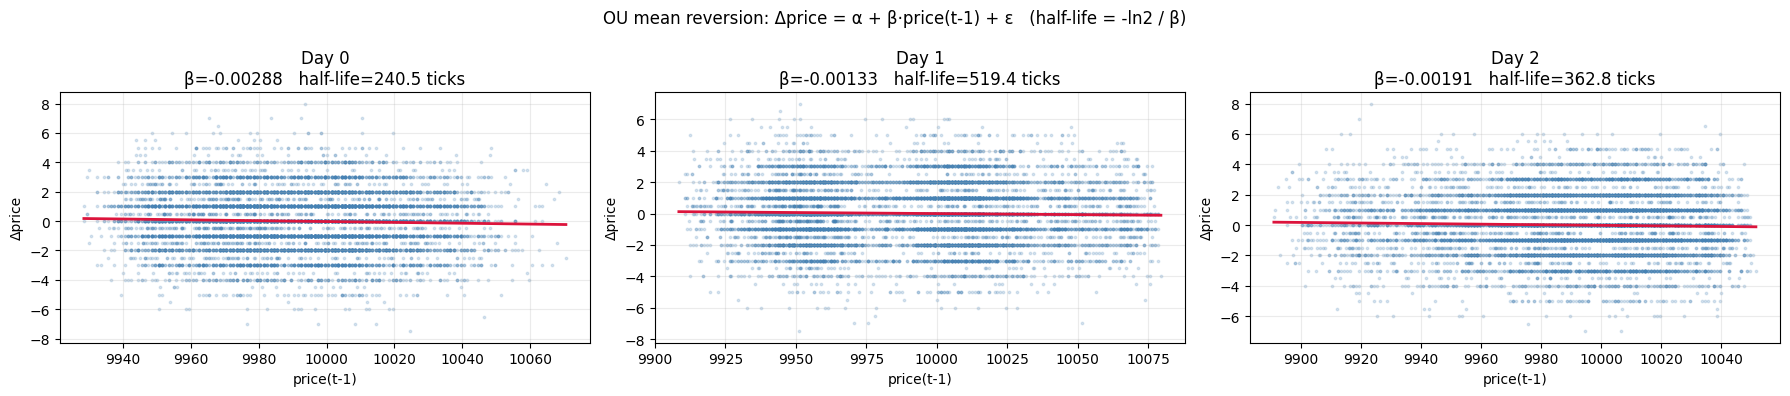


Half-life summary (expected ticks to cross mean from entry):
  Day 0: β=-0.002882,  half-life ≈ 240.5 ticks
  Day 1: β=-0.001334,  half-life ≈ 519.4 ticks
  Day 2: β=-0.00191,  half-life ≈ 362.8 ticks


In [52]:
import matplotlib.pyplot as plt
from scipy import stats

days = sorted(hydro["day"].unique())
fig, axes = plt.subplots(1, len(days), figsize=(6 * len(days), 4))
if len(days) == 1:
    axes = [axes]

hl_results = []
for ax, day in zip(axes, days):
    prices = hydro.loc[hydro["day"] == day, "fair_value"].values
    p_lag, delta_p = prices[:-1], np.diff(prices)

    beta, alpha, r, pval, _ = stats.linregress(p_lag, delta_p)
    half_life = -np.log(2) / beta if beta < 0 else np.inf
    hl_results.append({"day": day, "beta": round(beta, 6), "half_life_ticks": round(half_life, 1)})

    ax.scatter(p_lag, delta_p, s=3, alpha=0.2, color="steelblue", rasterized=True)
    x_fit = np.linspace(p_lag.min(), p_lag.max(), 200)
    ax.plot(x_fit, alpha + beta * x_fit, color="crimson", linewidth=2)
    ax.set_title(f"Day {day}\n\u03b2={beta:.5f}   half-life={half_life:.1f} ticks")
    ax.set_xlabel("price(t-1)")
    ax.set_ylabel("\u0394price")
    ax.grid(alpha=0.25)

fig.suptitle(
    "OU mean reversion: \u0394price = \u03b1 + \u03b2\u00b7price(t-1) + \u03b5   "
    "(half-life = -ln2 / \u03b2)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print("\nHalf-life summary (expected ticks to cross mean from entry):")
for r in hl_results:
    print(f"  Day {r['day']}: \u03b2={r['beta']},  half-life \u2248 {r['half_life_ticks']} ticks")


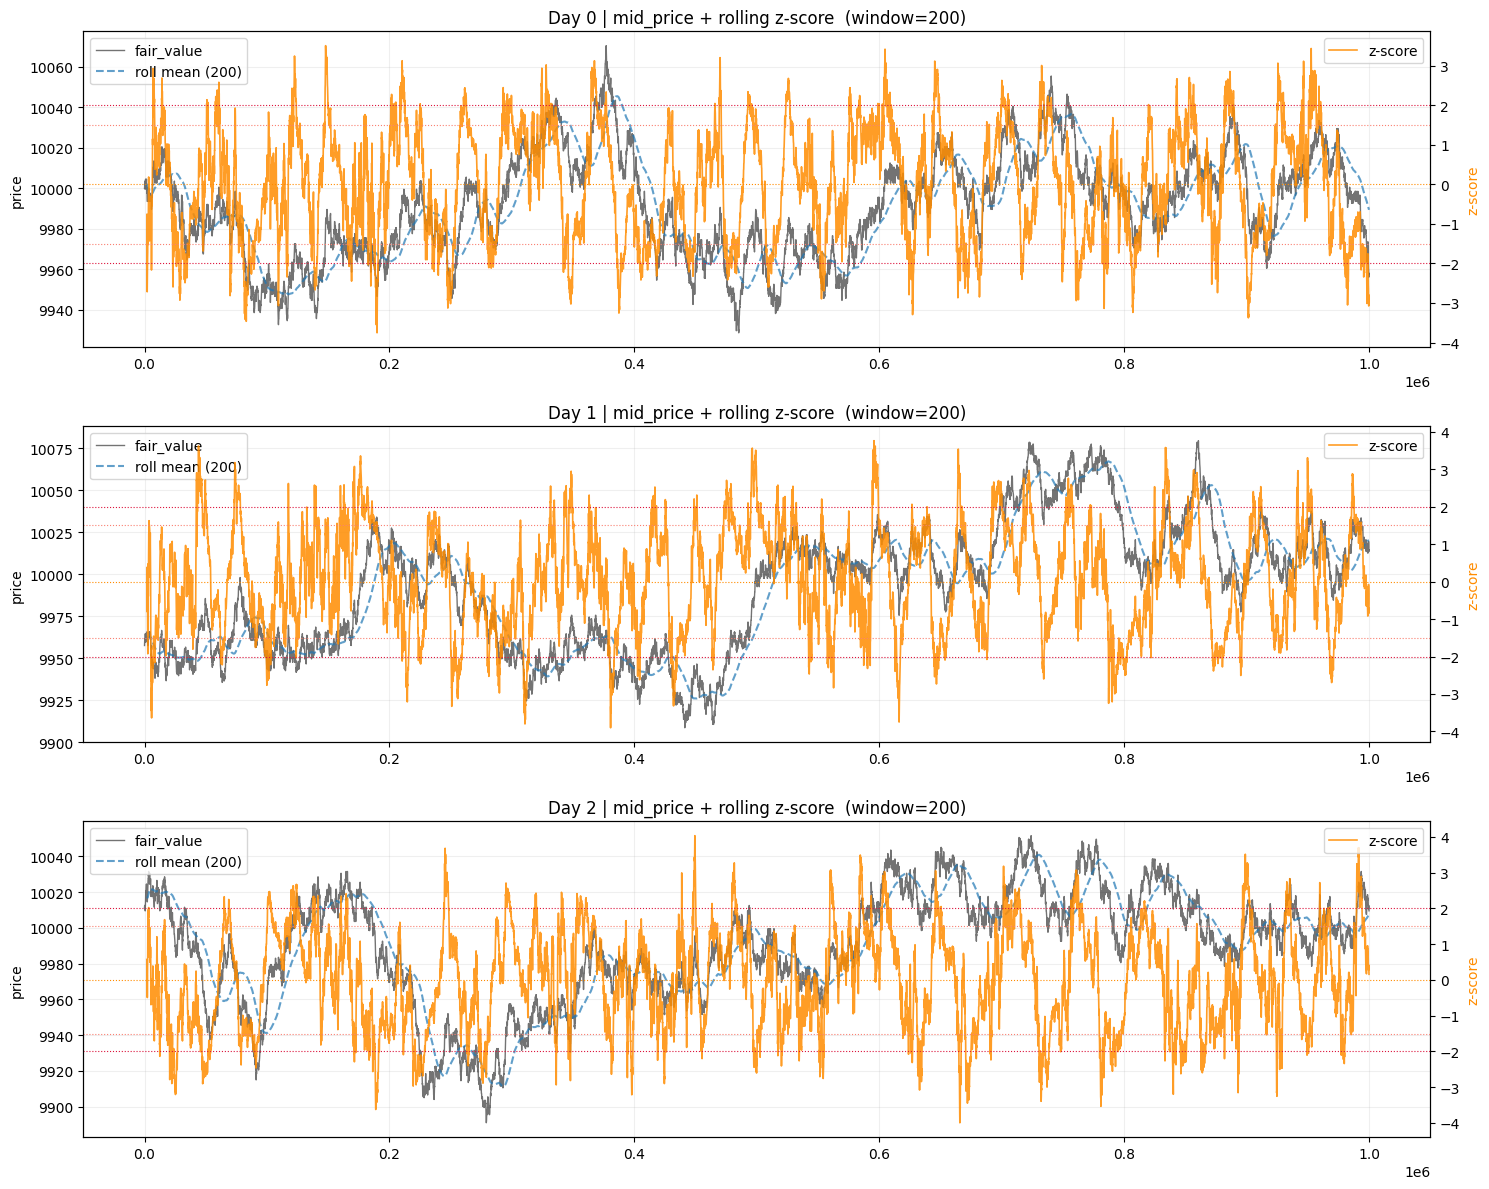

In [53]:
import matplotlib.pyplot as plt

ROLLING_WINDOW = 200   # tune to ~3-5x the half-life

days = sorted(hydro["day"].unique())
fig, axes = plt.subplots(len(days), 1, figsize=(15, 4 * len(days)))
if len(days) == 1:
    axes = [axes]

for ax, day in zip(axes, days):
    grp = hydro[hydro["day"] == day].copy()
    grp["roll_mean"] = grp["fair_value"].rolling(ROLLING_WINDOW, min_periods=20).mean()
    grp["roll_std"]  = grp["fair_value"].rolling(ROLLING_WINDOW, min_periods=20).std()
    grp["zscore"]    = (grp["fair_value"] - grp["roll_mean"]) / grp["roll_std"]

    ax2 = ax.twinx()
    ax.plot(grp["timestamp"], grp["fair_value"], color="black",      lw=1,   alpha=0.55, label="fair_value")
    ax.plot(grp["timestamp"], grp["roll_mean"], color="tab:blue",   lw=1.5, ls="--",   alpha=0.7,  label=f"roll mean ({ROLLING_WINDOW})")
    ax2.plot(grp["timestamp"], grp["zscore"],   color="darkorange", lw=1.2,            alpha=0.85, label="z-score")
    ax2.axhline(0,    color="darkorange", lw=0.8, ls=":")
    for z in [1.5, -1.5]:
        ax2.axhline(z, color="salmon",  lw=0.8, ls=":")
    for z in [2.0, -2.0]:
        ax2.axhline(z, color="crimson", lw=0.8, ls=":")

    ax.set_title(f"Day {day} | mid_price + rolling z-score  (window={ROLLING_WINDOW})")
    ax.set_ylabel("price")
    ax2.set_ylabel("z-score", color="darkorange")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


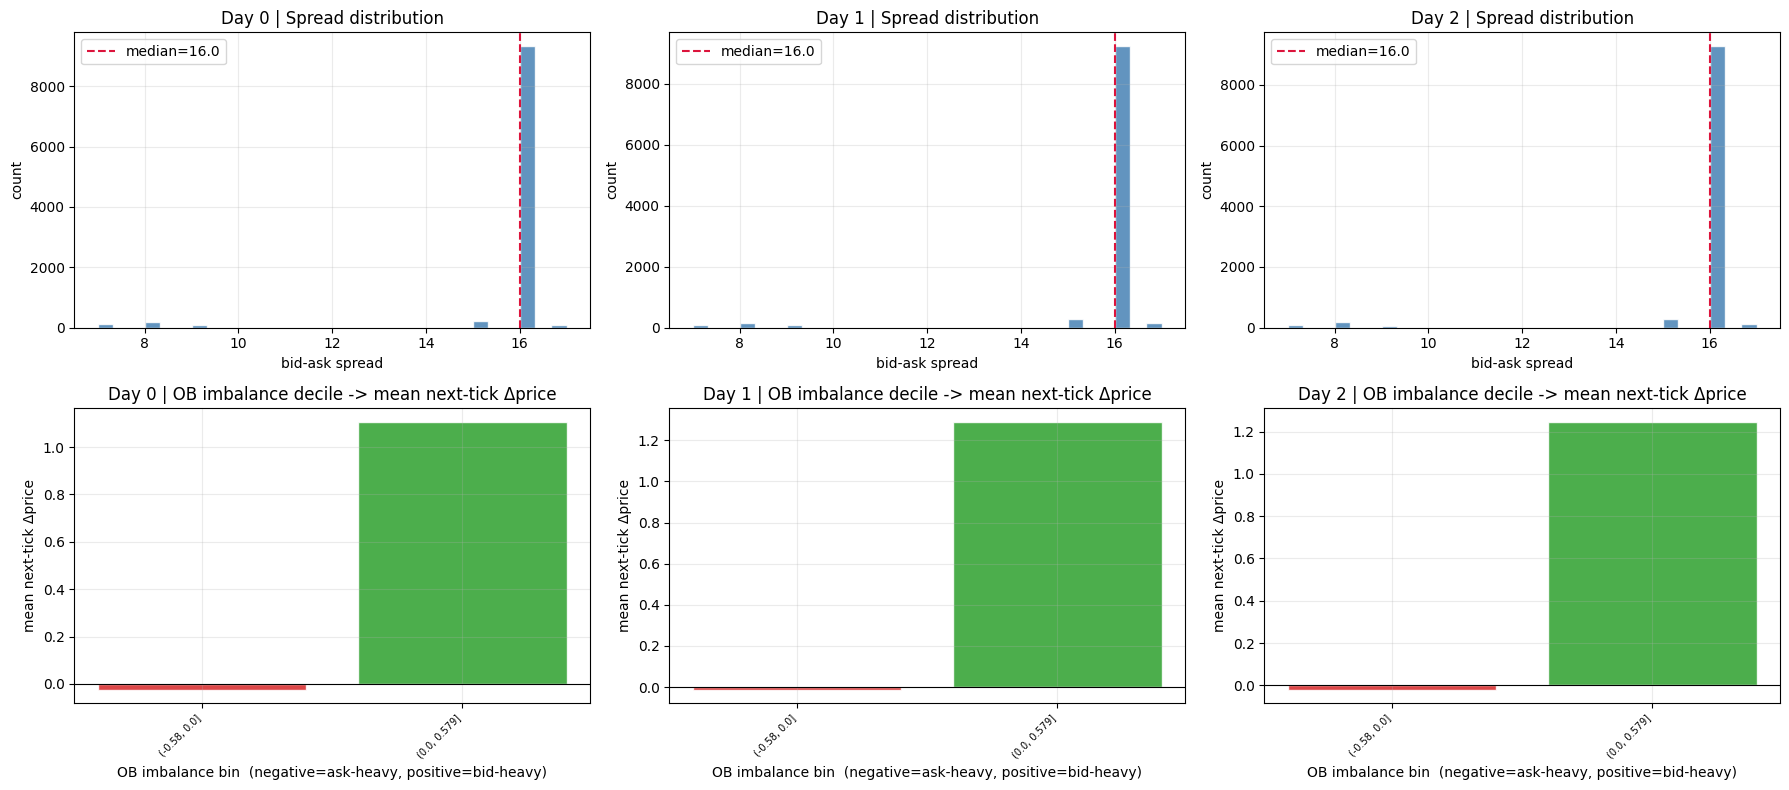

In [54]:
import matplotlib.pyplot as plt

hydro["spread"]       = hydro["ask_price_1"] - hydro["bid_price_1"]
hydro["ob_imbalance"] = (
    (hydro["bid_volume_1"] - hydro["ask_volume_1"]) /
    (hydro["bid_volume_1"] + hydro["ask_volume_1"] + 1e-9)
)
hydro["next_return"] = hydro.groupby("day")["fair_value"].diff(1).shift(-1)

days = sorted(hydro["day"].unique())
fig, axes = plt.subplots(2, len(days), figsize=(6 * len(days), 8))
if len(days) == 1:
    axes = axes.reshape(2, 1)

for col, day in enumerate(days):
    g = hydro[hydro["day"] == day]

    # Spread histogram
    s = g["spread"].dropna()
    axes[0, col].hist(s, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[0, col].axvline(s.median(), color="crimson", ls="--", label=f"median={s.median():.1f}")
    axes[0, col].set_title(f"Day {day} | Spread distribution")
    axes[0, col].set_xlabel("bid-ask spread")
    axes[0, col].set_ylabel("count")
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.25)

    # OB imbalance -> mean next-tick return per decile
    valid = g[["ob_imbalance", "next_return"]].dropna()
    valid = valid.copy()
    valid["imb_bin"] = pd.qcut(valid["ob_imbalance"], q=10, duplicates="drop")
    binned = valid.groupby("imb_bin", observed=True)["next_return"].mean()
    colors = ["tab:green" if v >= 0 else "tab:red" for v in binned.values]
    axes[1, col].bar(range(len(binned)), binned.values, color=colors, edgecolor="white", alpha=0.85)
    axes[1, col].set_xticks(range(len(binned)))
    axes[1, col].set_xticklabels([str(b) for b in binned.index], rotation=45, ha="right", fontsize=7)
    axes[1, col].axhline(0, color="black", lw=0.8)
    axes[1, col].set_title(f"Day {day} | OB imbalance decile -> mean next-tick \u0394price")
    axes[1, col].set_xlabel("OB imbalance bin  (negative=ask-heavy, positive=bid-heavy)")
    axes[1, col].set_ylabel("mean next-tick \u0394price")
    axes[1, col].grid(alpha=0.25)

plt.tight_layout()
plt.show()


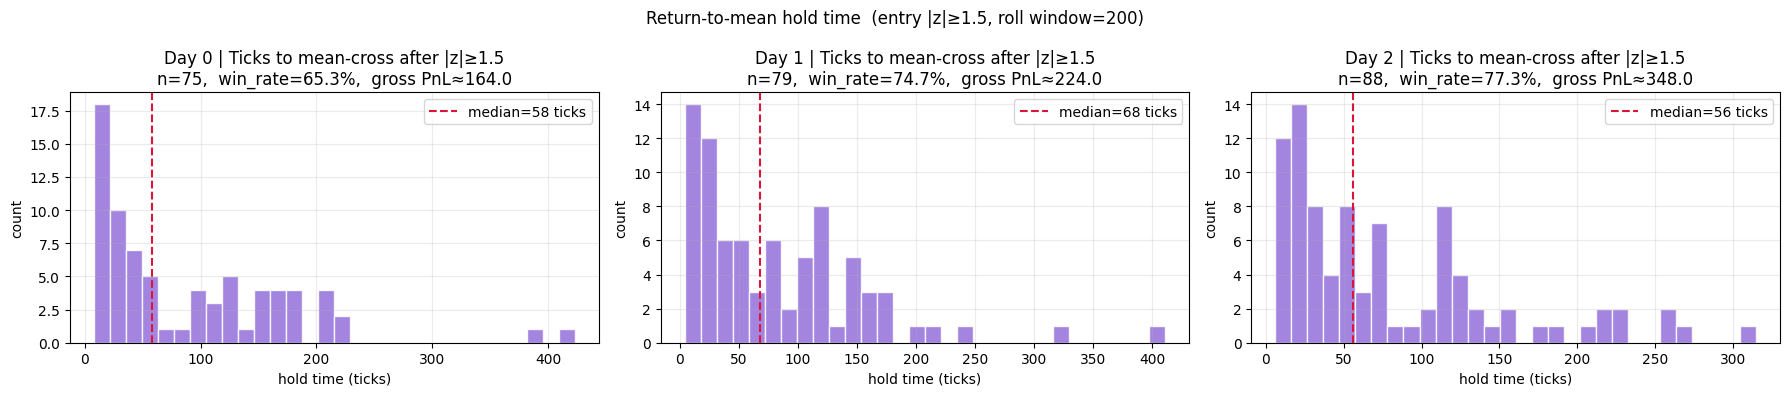

In [55]:
import matplotlib.pyplot as plt

ENTRY_ZSCORE   = 1.5
ROLLING_WINDOW = 200
MAX_HOLD       = 500  # cap search window; open at day-end are excluded

days = sorted(hydro["day"].unique())
fig, axes = plt.subplots(1, len(days), figsize=(6 * len(days), 4))
if len(days) == 1:
    axes = [axes]

for ax, day in zip(axes, days):
    grp = hydro[hydro["day"] == day].copy().reset_index(drop=True)
    grp["roll_mean"] = grp["fair_value"].rolling(ROLLING_WINDOW, min_periods=20).mean()
    grp["roll_std"]  = grp["fair_value"].rolling(ROLLING_WINDOW, min_periods=20).std()
    grp["zscore"]    = (grp["fair_value"] - grp["roll_mean"]) / grp["roll_std"]

    hold_times, pnls = [], []
    i = 0
    while i < len(grp) - 1:
        z = grp.at[i, "zscore"]
        if abs(z) >= ENTRY_ZSCORE and not np.isnan(z):
            sign = np.sign(z)
            entry_price = grp.at[i, "fair_value"]
            for j in range(i + 1, min(i + MAX_HOLD, len(grp))):
                zj = grp.at[j, "zscore"]
                if np.isnan(zj):
                    continue
                if np.sign(zj) != sign or zj == 0:
                    hold_times.append(j - i)
                    pnls.append(-sign * (grp.at[j, "fair_value"] - entry_price))
                    i = j
                    break
            else:
                i += 1
        else:
            i += 1

    if hold_times:
        ax.hist(hold_times, bins=30, color="mediumpurple", edgecolor="white", alpha=0.85)
        ax.axvline(np.median(hold_times), color="crimson", ls="--",
                   label=f"median={np.median(hold_times):.0f} ticks")
        win_rate  = sum(p > 0 for p in pnls) / len(pnls)
        gross_pnl = sum(pnls)
        ax.set_title(
            f"Day {day} | Ticks to mean-cross after |z|\u2265{ENTRY_ZSCORE}\n"
            f"n={len(hold_times)},  win_rate={win_rate:.1%},  gross PnL\u2248{gross_pnl:.1f}"
        )
        ax.set_xlabel("hold time (ticks)")
        ax.set_ylabel("count")
        ax.legend()
    else:
        ax.set_title(f"Day {day} | No entries at |z|\u2265{ENTRY_ZSCORE}")
    ax.grid(alpha=0.25)

fig.suptitle(
    f"Return-to-mean hold time  (entry |z|\u2265{ENTRY_ZSCORE}, roll window={ROLLING_WINDOW})",
    fontsize=12,
)
plt.tight_layout()
plt.show()


C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARIMA order for day 2: (1, 1, 0)
AIC=41756.88  BIC=41771.30
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                10000
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -20876.440
Date:                Sun, 26 Apr 2026   AIC                          41756.879
Time:                        01:36:32   BIC                          41771.300
Sample:                             0   HQIC                         41761.761
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0252      0.010     -2.533      0.011      -0.045      -0.006
sigma2         3.8108      0.054     71.013      0.000       3.706

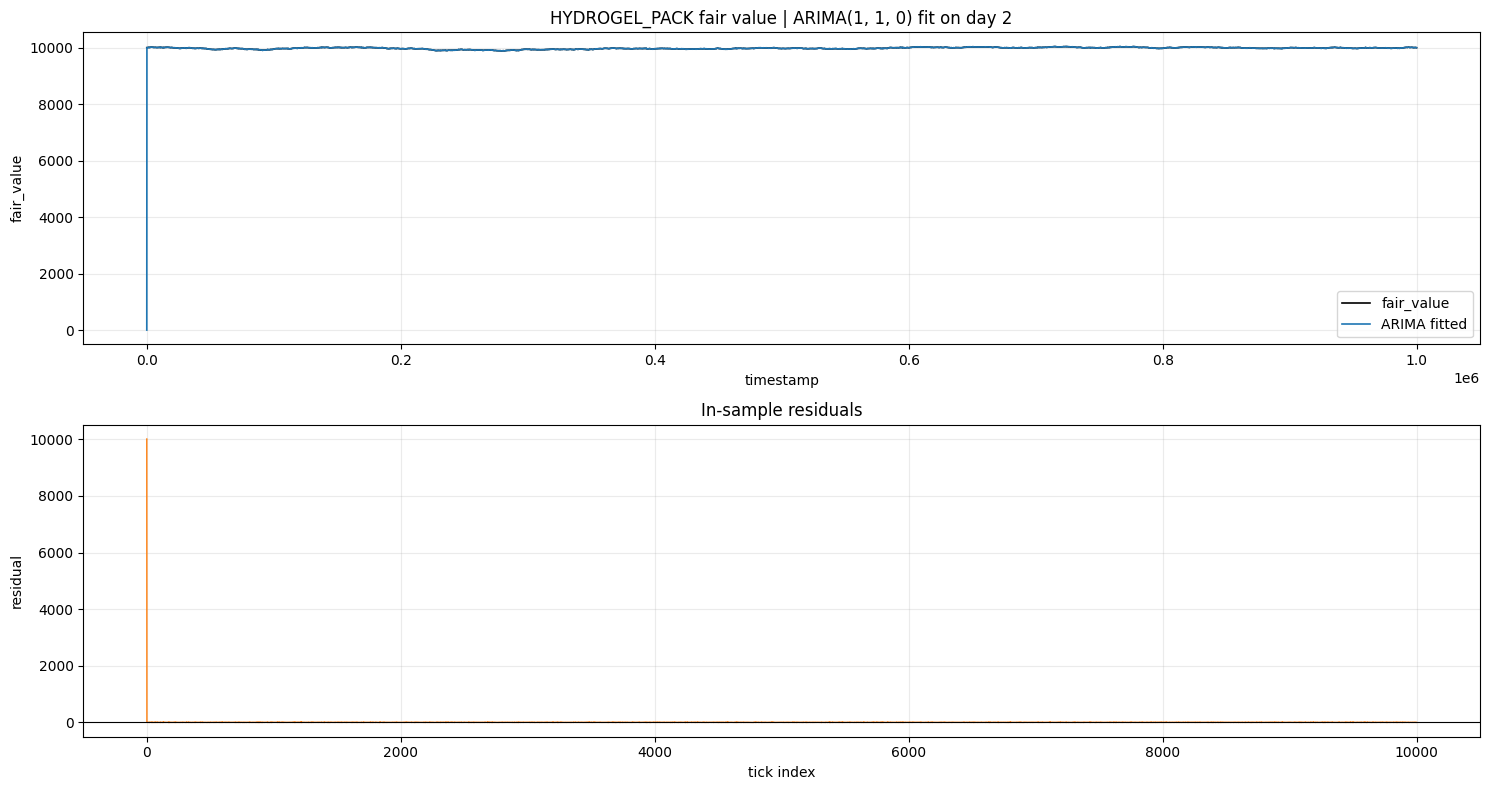

Forecast preview:


,step,forecast,lower_95,upper_95
0,1,10009.525191,10005.699109,10013.351273
1,2,10009.524557,10004.181379,10014.867734
2,3,10009.524573,10003.007034,10016.042111
3,4,10009.524572,10002.014139,10017.035006
4,5,10009.524572,10001.137980,10017.911165
5,6,10009.524572,10000.345071,10018.704074
6,7,10009.524572,9999.615406,10019.433738
7,8,10009.524572,9998.935905,10020.113240
8,9,10009.524572,9998.297453,10020.751691
9,10,10009.524572,9997.693405,10021.355740


In [59]:
# ARIMA fit for HYDROGEL_PACK fair value
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'hydro' not in globals():
    raise ValueError('Run the earlier hydrogel cells first so `hydro` exists.')

series = hydro[['day', 'timestamp', 'fair_value']].dropna().copy()
series = series.sort_values(['day', 'timestamp']).reset_index(drop=True)

if series.empty:
    raise ValueError('No fair_value rows available for HYDROGEL_PACK.')

# Fit on the last day by default; this avoids discontinuities across session boundaries.
target_day = int(series['day'].max())
day_series = series[series['day'] == target_day].copy()

if len(day_series) < 50:
    raise ValueError(f'Not enough observations on day {target_day} to fit ARIMA.')

y = day_series['fair_value'].astype(float).to_numpy()

# Small AIC grid search; keep orders modest for stability and speed.
orders = []
for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 4):
            if p == d == q == 0:
                continue
            try:
                fit = ARIMA(y, order=(p, d, q), trend='c' if d == 0 else 'n').fit()
                orders.append({
                    'order': (p, d, q),
                    'aic': float(fit.aic),
                    'bic': float(fit.bic),
                    'fit': fit,
                })
            except Exception:
                continue

if not orders:
    raise ValueError('No ARIMA model in the search grid converged.')

best = min(orders, key=lambda row: row['aic'])
best_fit = best['fit']
best_order = best['order']

print(f'Best ARIMA order for day {target_day}: {best_order}')
print(f'AIC={best_fit.aic:.2f}  BIC={best_fit.bic:.2f}')
print(best_fit.summary())

# One-step in-sample fitted values and short forecast.
fitted = best_fit.fittedvalues
resid = best_fit.resid

forecast_horizon = min(25, max(5, len(y) // 20))
forecast = best_fit.get_forecast(steps=forecast_horizon)
forecast_mean = np.asarray(forecast.predicted_mean)
forecast_ci = np.asarray(forecast.conf_int())

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
axes[0].plot(day_series['timestamp'], y, color='black', linewidth=1.2, label='fair_value')
axes[0].plot(day_series['timestamp'].iloc[:len(fitted)], fitted, color='tab:blue', linewidth=1.2, label='ARIMA fitted')
axes[0].set_title(f'HYDROGEL_PACK fair value | ARIMA{best_order} fit on day {target_day}')
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('fair_value')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(resid, color='tab:orange', linewidth=1.0)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('In-sample residuals')
axes[1].set_xlabel('tick index')
axes[1].set_ylabel('residual')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print('Forecast preview:')
forecast_table = pd.DataFrame({
    'step': np.arange(1, forecast_horizon + 1),
    'forecast': forecast_mean,
    'lower_95': forecast_ci[:, 0],
    'upper_95': forecast_ci[:, 1],
})
display(forecast_table)
